### **Falcon9 DQN TORCH using Classes and 2 Networks**

This notebook mirrors the LunarLander DQN example, but the environment is the new Gymnasium-compatible `Falcon9-v0` Box2D environment from the root `falcon9` package.

The learning problem is harder than classic LunarLander because the target platform moves horizontally, the rocket starts high above the platform, the vehicle has a limited jet-fire budget, and the state includes platform-relative information.

Falcon9 inspired on Anthony Burkov future book on RL

In [1]:
import os
import random
import sys
import time
from collections import deque
import importlib

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image

# Importing this module registers the environment id `Falcon9-v0` with Gymnasium.
# Reloading is useful in notebooks because Gymnasium can keep an old registry
# entry alive while you are editing the local environment code.
import falcon9
import falcon9.falcon9 as falcon9_env
importlib.reload(falcon9_env)
importlib.reload(falcon9)
falcon9.register_falcon9_env()

# Keep notebook stderr noise in one file, as in the LunarLander notebook.
sys.stderr = open("err.txt", "w")

In [2]:
# Reproducibility: DQN is still stochastic, but these seeds make comparisons fairer.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Training device:", device)

PyTorch version: 2.11.0+cu130
CUDA available: True
Training device: cuda


#### **Hyperparameters**

DQN learns a value for every discrete action. `Falcon9-v0` has four actions: no-op, left attitude jet, main engine, and right attitude jet.

In [3]:
# Set this to True when you actually want to train.
RUN_TRAINING = False

MAX_EPISODES = 5000
ROLLING_WINDOW = 100
MEMORY_SIZE = 100_000
MAX_STEPS = 1200

gamma = 0.99

epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.999

learning_rate = 3e-4
batch_size = 128
solved_threshold = 60
REFRESH_TARGET_NET = 500

In [4]:
# Gymnasium creates the environment through the registered id.
# The default discrete action space is appropriate for DQN.
env = gym.make("Falcon9-v0", dashboard=True, max_episode_steps=MAX_STEPS)
state_size = int(env.observation_space.shape[0])
action_size = int(env.action_space.n)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("state_size:", state_size, "action_size:", action_size)

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
   0.          0.         -1.         -2.          0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.         1.         2.         1.       ], (11,), float32)
Action space: Discrete(4)
state_size: 11 action_size: 4


#### **Falcon9 Environment Dynamics**

The `Falcon9-v0` environment is a Box2D rigid-body control task. The rocket is modeled as one dynamic body composed of three polygon fixtures: the central booster body, the left landing foot, and the right landing foot. The feet are part of the same rigid body, so they do not articulate independently. The moving ocean platform is a kinematic Box2D body that slides horizontally and reverses direction at the screen boundaries.

At reset, the platform starts at a random horizontal position and direction. The booster starts high above the platform, horizontally aligned with it, with a random initial tilt between `-45` and `+45` degrees and zero angular velocity. This means the agent must learn both attitude control and vertical speed control before touchdown.

The discrete action space has four actions:

- `0`: do nothing.
- `1`: fire the upper-left attitude jet.
- `2`: fire the main bottom engine.
- `3`: fire the upper-right attitude jet.

The main engine applies an impulse along the rocket's current body axis. If the rocket is tilted, firing the main engine also pushes it sideways. The attitude jets apply small off-center impulses near the top of the rocket, creating angular acceleration. Because the platform is moving, the useful horizontal velocity is the rocket velocity relative to the platform, not relative to the screen.

The observation has 11 values:

1. relative horizontal position to the platform target,
2. relative vertical position to the landing height,
3. relative horizontal velocity,
4. vertical velocity,
5. rocket angle,
6. angular velocity,
7. left foot contact flag,
8. right foot contact flag,
9. platform horizontal position,
10. platform horizontal velocity,
11. fraction of jet fires remaining.

The reward has two parts. During flight, dense shaping rewards being centered over the platform, moving slowly, staying upright, reducing angular velocity, and touching down with the feet. Engine use has a small cost. At the end of an episode, a successful landing receives the success reward, while crashes, hard impacts, unstable landings, ocean contact, out-of-bounds episodes, and timeouts receive the failure reward.

A key detail is that landing is not just `touch the platform`. A ballistic fall with no engine should fail because the platform impact velocity is too high. The environment therefore checks impact speed, angular speed, body contact, and stable foot contact before success. This makes the task much harder than classic LunarLander, but it prevents the agent from learning the bad shortcut of doing nothing and still receiving a landing reward.

This difficulty matters for DQN. Early replay memory is dominated by crashes, and successful trajectories are rare. The agent must discover a sequence that uses the main engine to slow descent and the side jets to stay upright. Because the positive terminal reward is delayed, convergence can be slow unless exploration, reward shaping, replay balance, or curriculum are tuned carefully.


#### **Q Network**

The network receives one Falcon9 observation and returns four Q-values, one for each action. The highest Q-value is the action the current policy prefers.

In [5]:
class Q_Network(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_size),
        )

    def forward(self, x):
        return self.net(x)   # ← no self.relu here

#### **DQN Agent**

The agent owns two networks. The online network is updated every replay step. The target network changes more slowly, which stabilizes the bootstrap target.

In [6]:
class Agent_DQN:
    def __init__(self, states, actions, alpha, gamma, epsilon):
        self.nS = states
        self.nA = actions
        self.replay_buffer = deque([], maxlen=MEMORY_SIZE)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.model = self.build_NN()
        self.target_model = self.build_NN()
        self.update_target_network()

        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate)
        self.loss_fn = nn.HuberLoss(delta=1.0)                    # original nn.MSELoss() 
        self.loss = []
        self.step_count = 0

    def build_NN(self):
        return Q_Network(self.nS, self.nA).to(device)

    def update_target_network(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def action(self, state):
        # Accept either a flat observation or a batch with one observation.
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device)
        if state_tensor.ndim == 1:
            state_tensor = state_tensor.unsqueeze(0)

        self.model.eval()
        with torch.no_grad():
            action_vals = self.model(state_tensor)
        self.model.train()
        return torch.argmax(action_vals, dim=1).item()

    def random_action(self):
        return random.randrange(self.nA)

    def store_experience(self, state, action, reward, next_state, done):
        self.replay_buffer.append((state, action, reward, next_state, done))

    def sample_experiences(self, batch_size):
        indices = np.random.choice(len(self.replay_buffer), batch_size, replace=False)
        batch = [self.replay_buffer[i] for i in indices]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.asarray(states, dtype=np.float32),
            np.asarray(actions, dtype=np.int64),
            np.asarray(rewards, dtype=np.float32),
            np.asarray(next_states, dtype=np.float32),
            np.asarray(dones, dtype=np.float32),
        )

    def experience_replay(self, batch_size):
        if len(self.replay_buffer) < batch_size:
            return

        self.step_count += 1
        states, actions, rewards, next_states, dones = self.sample_experiences(batch_size)

        states_tensor = torch.as_tensor(states, dtype=torch.float32, device=device)
        actions_tensor = torch.as_tensor(actions, dtype=torch.long, device=device)
        rewards_tensor = torch.as_tensor(rewards, dtype=torch.float32, device=device)
        next_states_tensor = torch.as_tensor(next_states, dtype=torch.float32, device=device)
        dones_tensor = torch.as_tensor(dones, dtype=torch.float32, device=device)

        q_values = self.model(states_tensor)
        selected_q_values = q_values.gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_model(next_states_tensor).max(dim=1).values
            target_q_values = rewards_tensor + self.gamma * next_q_values * (1 - dones_tensor)

        loss = self.loss_fn(selected_q_values, target_q_values)
        self.optimizer.zero_grad()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=10.0)      # Gradient Clipping
        self.optimizer.step()
        self.loss.append(loss.item())

        if self.step_count % REFRESH_TARGET_NET == 0:
            self.update_target_network()

In [7]:
def select_action_epsilon_greedy(state, agent):
    # Exploration is important early because the agent has no idea how engines affect the rocket.
    if np.random.rand() <= agent.epsilon:
        return agent.random_action()
    return agent.action(state)

#### **Main Training Loop**

Each step stores one transition in replay memory. After enough transitions exist, the agent samples random mini-batches to reduce correlation between consecutive physics states.

In [8]:
agent = Agent_DQN(state_size, action_size, learning_rate, gamma, epsilon)
rewards_per_episode = []
rolling_avg_rewards = []


start_time = time.time()

for episode in range(1, MAX_EPISODES + 1):
    state, _ = env.reset(seed=SEED + episode)
    episode_reward = 0.0

    for step in range(1, MAX_STEPS + 1):
        action = select_action_epsilon_greedy(state, agent)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        agent.epsilon = max(agent.epsilon_min, agent.epsilon * agent.epsilon_decay)
        agent.store_experience(state, action, reward, next_state, done)
        agent.experience_replay(batch_size)

        state = next_state
        episode_reward += reward

        if done:
            break

    
    rewards_per_episode.append(episode_reward)
    rolling_avg = np.mean(rewards_per_episode[-ROLLING_WINDOW:])
    rolling_avg_rewards.append(rolling_avg)

    print(
        f"Episode: {episode:4}/{MAX_EPISODES}, "
        f"Reward: {episode_reward:+8.2f}, "
        f"Epsilon: {agent.epsilon:.2f}, "
        f"Rolling Avg: {rolling_avg:+8.2f}, "
        f"Steps: {step:4}, "
        f"Success: {info.get('success')}"
    )

    if rolling_avg >= solved_threshold and episode >= ROLLING_WINDOW:
        print(f"Solved after {episode} episodes with rolling average {rolling_avg:.2f}")
        break

print(f"Training completed in {(time.time() - start_time) / 60:.2f} minutes")

Episode:    1/5000, Reward:  -546.73, Epsilon: 0.84, Rolling Avg:  -546.73, Steps:  171, Success: False
Episode:    2/5000, Reward:  -195.29, Epsilon: 0.74, Rolling Avg:  -371.01, Steps:  127, Success: False
Episode:    3/5000, Reward:  -626.23, Epsilon: 0.67, Rolling Avg:  -456.09, Steps:   97, Success: False
Episode:    4/5000, Reward:  -343.75, Epsilon: 0.57, Rolling Avg:  -428.00, Steps:  168, Success: False
Episode:    5/5000, Reward:  -329.03, Epsilon: 0.48, Rolling Avg:  -408.21, Steps:  179, Success: False
Episode:    6/5000, Reward:  -238.78, Epsilon: 0.41, Rolling Avg:  -379.97, Steps:  161, Success: False
Episode:    7/5000, Reward:  -625.00, Epsilon: 0.33, Rolling Avg:  -414.97, Steps:  216, Success: False
Episode:    8/5000, Reward:  +308.55, Epsilon: 0.29, Rolling Avg:  -324.53, Steps:  124, Success: True
Episode:    9/5000, Reward:  -242.11, Epsilon: 0.26, Rolling Avg:  -315.38, Steps:  115, Success: False
Episode:   10/5000, Reward:  -335.11, Epsilon: 0.22, Rolling Avg:

#### **Learning Plot**

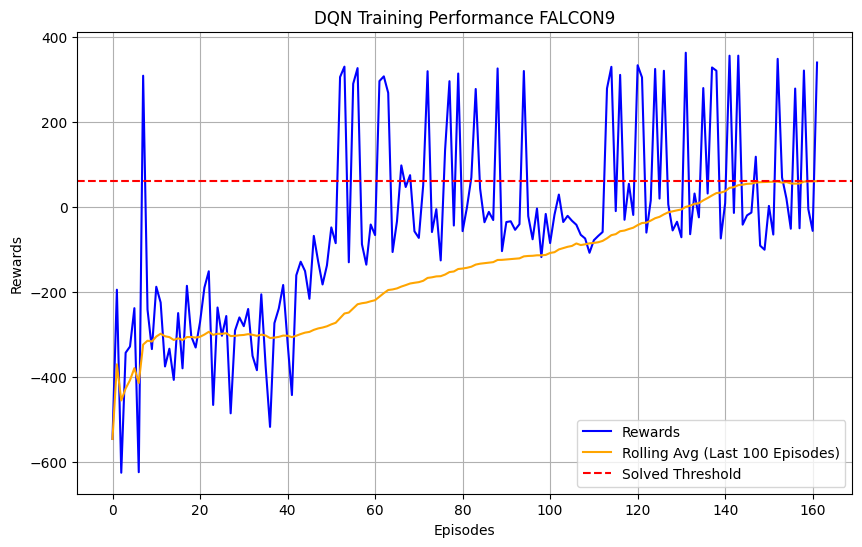

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(rewards_per_episode, label="Rewards", color="blue")
plt.plot(rolling_avg_rewards, label=f"Rolling Avg (Last {ROLLING_WINDOW} Episodes)", color="orange")
plt.axhline(y=solved_threshold, color="red", linestyle="--", label="Solved Threshold")
plt.title("DQN Training Performance FALCON9")
plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.legend()
plt.grid()
plt.show()

#### **Testing Episodes**

In [10]:
for episode in range(10):
    state, _ = env.reset(seed=10_000 + episode)
    total_reward = 0.0

    for step in range(1, MAX_STEPS + 1):
        action = agent.action(state)
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            print(
                f"Test Episode: {episode + 1:2}/10, "
                f"Reward: {total_reward:.2f}, Steps: {step:4}, "
                f"Success: {info.get('success')}"
            )
            break

Test Episode:  1/10, Reward: 326.88, Steps:  125, Success: True
Test Episode:  2/10, Reward: 312.85, Steps:  268, Success: True
Test Episode:  3/10, Reward: 326.96, Steps:  104, Success: True
Test Episode:  4/10, Reward: 372.02, Steps:  327, Success: True
Test Episode:  5/10, Reward: -55.78, Steps:   73, Success: False
Test Episode:  6/10, Reward: -8.79, Steps:   77, Success: False
Test Episode:  7/10, Reward: -66.80, Steps:   73, Success: False
Test Episode:  8/10, Reward: -38.61, Steps:   74, Success: False
Test Episode:  9/10, Reward: 339.69, Steps:  155, Success: True
Test Episode: 10/10, Reward: 333.06, Steps:  380, Success: True


#### **Rendering 1 Episode**

In [14]:
RUN_RENDERING = False
GIF_FRAME_MS = 80

def save_frames_as_gif(frames, path="./", filename="FALCON9_Agent_DQN.gif"):
    if not frames:
        print("No frames were collected.")
        return
    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(gif_path, save_all=True, append_images=images[1:], duration=GIF_FRAME_MS, loop=0)
    print(f"Saved GIF to: {gif_path}")

render_env = gym.make("Falcon9-v0", render_mode="rgb_array", dashboard=True, max_episode_steps=MAX_STEPS)
frames = []
state, _ = render_env.reset(seed = 42)
total_reward = 0.0

# Capture and hold the reset frame. Without this, the GIF starts after the
# first physics step, and the rocket may already be close to the visible area.
reset_frame = render_env.render()
frames.extend([reset_frame] * 8)

for step in range(1, MAX_STEPS + 1):
    # Capture the state before the action. This is important for terminal
    # landings because the environment settles the rocket upright on success.
    frames.append(render_env.render())
    action = agent.action(state)
    state, reward, terminated, truncated, info = render_env.step(action)
    total_reward += reward

    if terminated or truncated:
        terminal_frame = render_env.render()
        frames.extend([terminal_frame] * 12)
        print(f"Rendered Test Episode Reward: {total_reward:.2f}")
        break

render_env.close()
save_frames_as_gif(frames)


Rendered Test Episode Reward: 358.63
Saved GIF to: ./FALCON9_Agent_DQN.gif


In [12]:
import session_info
session_info.show(html=False)

env.close()

-----
PIL                 12.1.0
falcon9             NA
gymnasium           1.2.2
matplotlib          3.10.8
numpy               2.1.3
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1021-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-06-07 12:07
